In [1]:
import numpy as np
import pandas as pd
import xarray as xr
from functools import reduce
import matplotlib.pyplot as plt
from idlpy import *
from scipy import stats
import statsmodels.api as sm
from scipy.stats import percentileofscore
import scipy

import cartopy.crs as ccrs

IDL 8.7.2 (linux x86_64 m64).
(c) 2019, Harris Geospatial Solutions, Inc.

Licensed for use by: NIWA - National Institute of Water and Atmospheric Research Ltd - Ashley
License: 335119


In [49]:
def q_map_to_gaussian(da, dist):
    
    # create container for corrected values
    gaussian = []
    
    for lat in da.lat:
        for lon in da.lon:

            ts = da.sel(lat=lat,lon=lon).values
            full_dist = dist.sel(lat=lat,lon=lon).values
            
            if np.isnan(np.sum(ts)):
                corrected_ts = [np.nan for i in range(len(ts))]

            else:
                corrected_ts = []
                for val in ts:
                    
                    # find percentile of value within the distribution of observations
                    percentile = percentileofscore(full_dist, val, kind= 'mean')
                    
                    if percentile == 100 or percentile == 0:
                        print('issue')

                    # replace with corresponding percentile value in norm distribution
                    corrected_ts.append(scipy.stats.norm.ppf(percentile/100, loc=0, scale=1))

            gaussian.append(corrected_ts)

    gaussian = np.array(gaussian).reshape((len(da.lat),len(da.lon),len(da.time)))
    
    gaussian_da = xr.DataArray(data = gaussian,
                               dims = ('lat', 'lon','time'),
                               coords = {'lat':da.lat.values,
                                         'lon':da.lon.values,
                                         'time':da.time.values
                                        }
                               )
    return(gaussian_da)


In [6]:
'''
Monthly (raw) ensemble mean data arrays
'''

# land/sea mask
ECHAM5_land_mask = xr.open_dataset('/home/stoneda/data/C20C/NOAA-ESRLandCIRES/ECHAM5-4/All-Hist/est1/v1-0/fx/atmos/sftlf/ens00/sftlf_fx_ECHAM5-4_All-Hist_est1_v1-0_ens00_000000-000000.nc')
ECHAM5_land_mask = ECHAM5_land_mask.sel(lon = slice(165,180),lat=slice(-33,-48))

# all-forcing ensemble mean
ECHAM5_ds_all = xr.open_dataset('/home/stoneda/data/C20C/NOAA-ESRLandCIRES/ECHAM5-4/All-Hist/est1/v1-0/mon/atmos/pr/ensmean/pr_Amon_ECHAM5-4_All-Hist_est1_v1-0_mean_197901-202102.nc')
ECHAM5_ds_all = ECHAM5_ds_all.sel(lon = slice(165,180),lat=slice(-33,-48))
ECHAM5_pr_all = ECHAM5_ds_all.pr.where(ECHAM5_land_mask.sftlf > 0)
# nat-forcing ensemble mean
ECHAM5_ds_nat = xr.open_dataset('/home/stoneda/data/C20C/NOAA-ESRLandCIRES/ECHAM5-4/Nat-Hist/obs-trend-1880s-est1/v1-0/mon/atmos/pr/ensmean/pr_Amon_ECHAM5-4_Nat-Hist_obs-trend-1880s-est1_v1-0_mean_197901-202006.nc')
ECHAM5_ds_nat = ECHAM5_ds_nat.sel(lon = slice(165,180),lat=slice(-33,-48))
ECHAM5_pr_nat = ECHAM5_ds_nat.pr.where(ECHAM5_land_mask.sftlf > 0)
# store means for fingerprinting
ens_means = {'all':ECHAM5_pr_all, 'nat':ECHAM5_pr_nat}

# ERA5 precip, coarsened to ECHAM5 resolution
ERA5_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/monthly/1969_2019.nc')
ERA5_ds = ERA5_ds.coarsen(latitude=3,longitude=3,boundary='pad').mean()
ERA5_ds = ERA5_ds.interp(longitude=ECHAM5_pr_all.lon, latitude=ECHAM5_pr_all.lat, method="linear")
ERA5_tp = ERA5_ds.tp.where(ECHAM5_land_mask.sftlf > 0)


In [51]:
'''
Creating dataarrays of FULL All-forcing distributions (concatenate all ensemble members over time) for annual, seasonal pr
'''

seasons_a = ['autumn','winter','spring','summer']


# SEASONAL
path = '/home/stoneda/data/C20C/NOAA-ESRLandCIRES/ECHAM5-4/All-Hist/est1/v1-0/mon/atmos/pr/ens'
file_name_setup = ['pr_Amon_ECHAM5-4_All-Hist_est1_v1-0_ens','_197901-202102.nc']
all_seasonal_dist = {}
for i,s in enumerate([3,6,9,12]):

    da_list = []
    for ens_mem in range(1,51):
        number = '0' + str(ens_mem) if ens_mem < 10 else str(ens_mem)
        file_path = path + number + "/" + file_name_setup[0]+number+file_name_setup[1]
        ens_mem = xr.open_dataset(file_path)

        ens_mem = ens_mem.sel(lon = slice(165,180),lat=slice(-33,-48))
        ens_mem = ens_mem.pr.where(ECHAM5_land_mask.sftlf > 0)

        ens_mem_seasonal = ens_mem.resample(time='QS-DEC').mean()
        ens_mem_seasonal = ens_mem_seasonal.sel(time=slice('1978-12-01','2019-09-01'))
        
        ens_mem_season = ens_mem_seasonal.sel(time=ens_mem_seasonal.time.dt.month.isin([s]))

        da_list.append(ens_mem_season)

    season_full_dist = xr.concat(da_list,dim="time")
    all_seasonal_dist[seasons_a[i]] = season_full_dist
    
path = '/home/stoneda/data/C20C/NOAA-ESRLandCIRES/ECHAM5-4/Nat-Hist/obs-trend-1880s-est1/v1-0/mon/atmos/pr/ens'
file_name_setup = ['pr_Amon_ECHAM5-4_Nat-Hist_obs-trend-1880s-est1_v1-0_ens','_197901-202006.nc']
nat_seasonal_dist = {}
for i,s in enumerate([3,6,9,12]):

    da_list = []
    for ens_mem in range(1,51):
        number = '0' + str(ens_mem) if ens_mem < 10 else str(ens_mem)
        file_path = path + number + "/" + file_name_setup[0]+number+file_name_setup[1]
        ens_mem = xr.open_dataset(file_path)

        ens_mem = ens_mem.sel(lon = slice(165,180),lat=slice(-33,-48))
        ens_mem = ens_mem.pr.where(ECHAM5_land_mask.sftlf > 0)

        ens_mem_seasonal = ens_mem.resample(time='QS-DEC').mean()
        ens_mem_seasonal = ens_mem_seasonal.sel(time=slice('1978-12-01','2019-09-01'))
        
        ens_mem_season = ens_mem_seasonal.sel(time=ens_mem_seasonal.time.dt.month.isin([s]))

        da_list.append(ens_mem_season)

    season_full_dist = xr.concat(da_list,dim="time")
    nat_seasonal_dist[seasons_a[i]] = season_full_dist
    

In [53]:
'''
gaussian-ifying annual and seasonal pr for each ensemble member
'''

seasons_a = ['autumn','winter','spring','summer']


for scen in ['all','nat']:
    #print(scen)

    if scen == 'all':
        path = '/home/stoneda/data/C20C/NOAA-ESRLandCIRES/ECHAM5-4/All-Hist/est1/v1-0/mon/atmos/pr/ens'
        file_name_setup = ['pr_Amon_ECHAM5-4_All-Hist_est1_v1-0_ens','_197901-202102.nc']
        full_seasonal_dist = all_seasonal_dist
    if scen == 'nat':
        path = '/home/stoneda/data/C20C/NOAA-ESRLandCIRES/ECHAM5-4/Nat-Hist/obs-trend-1880s-est1/v1-0/mon/atmos/pr/ens'
        file_name_setup = ['pr_Amon_ECHAM5-4_Nat-Hist_obs-trend-1880s-est1_v1-0_ens','_197901-202006.nc']
        full_seasonal_dist = nat_seasonal_dist

    for ens_mem in range(1,51):
        
        #print(ens_mem)
        
        number = '0' + str(ens_mem) if ens_mem < 10 else str(ens_mem)
        file_path = path + number + "/" + file_name_setup[0]+number+file_name_setup[1]
        ens_mem = xr.open_dataset(file_path)
        
        ens_mem = ens_mem.sel(lon = slice(165,180),lat=slice(-33,-48))
        ens_mem = ens_mem.pr.where(ECHAM5_land_mask.sftlf > 0)

        ens_mem_annual = ens_mem.resample(time='A').mean()
        ens_mem_annual = ens_mem_annual.sel(time=slice('1979','2019'))
        #ens_mem_annual_gaussian = q_map_to_gaussian(ens_mem_annual,full_annual_dist)
        #ens_mem_annual_gaussian.to_netcdf("/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/gaussian/precip/annual/ECHAM5_"+scen+"_annual_pr_gaussian_ens" + number + ".nc")
        
        ens_mem_seasonal = ens_mem.resample(time='QS-DEC').mean()
        ens_mem_seasonal = ens_mem_seasonal.sel(time=slice('1978-12-01','2019-09-01'))
        
        for i,s in enumerate([3,6,9,12]):
            
            #print(s)
            
            ens_mem_season = ens_mem_seasonal.sel(time=ens_mem_seasonal.time.dt.month.isin([s]))

            ens_mem_season_gaussian = q_map_to_gaussian(ens_mem_season,full_seasonal_dist[seasons_a[i]])
            ens_mem_season_gaussian.to_netcdf("/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/gaussian/precip/seasonal/ECHAM5_"+scen+"_"+seasons_a[i]+"_pr_gaussian_ens"+number+".nc")
            

all
1
3
6
9
12
2
3
6
9
12
3
3
6
9
12
4
3
6
9
12
5
3
6
9
12
6
3
6
9
12
7
3
6
9
12
8
3
6
9
12
9
3
6
9
12
10
3
6
9
12
11
3
6
9
12
12
3
6
9
12
13
3
6
9
12
14
3
6
9
12
15
3
6
9
12
16
3
6
9
12
17
3
6
9
12
18
3
6
9
12
19
3
6
9
12
20
3
6
9
12
21
3
6
9
12
22
3
6
9
12
23
3
6
9
12
24
3
6
9
12
25
3
6
9
12
26
3
6
9
12
27
3
6
9
12
28
3
6
9
12
29
3
6
9
12
30
3
6
9
12
31
3
6
9
12
32
3
6
9
12
33
3
6
9
12
34
3
6
9
12
35
3
6
9
12
36
3
6
9
12
37
3
6
9
12
38
3
6
9
12
39
3
6
9
12
40
3
6
9
12
41
3
6
9
12
42
3
6
9
12
43
3
6
9
12
44
3
6
9
12
45
3
6
9
12
46
3
6
9
12
47
3
6
9
12
48
3
6
9
12
49
3
6
9
12
50
3
6
9
12
nat
1
3
6
9
12
2
3
6
9
12
3
3
6
9
12
4
3
6
9
12
5
3
6
9
12
6
3
6
9
12
7
3
6
9
12
8
3
6
9
12
9
3
6
9
12
10
3
6
9
12
11
3
6
9
12
12
3
6
9
12
13
3
6
9
12
14
3
6
9
12
15
3
6
9
12
16
3
6
9
12
17
3
6
9
12
18
3
6
9
12
19
3
6
9
12
20
3
6
9
12
21
3
6
9
12
22
3
6
9
12
23
3
6
9
12
24
3
6
9
12
25
3
6
9
12
26
3
6
9
12
27
3
6
9
12
28
3
6
9
12
29
3
6
9
12
30
3
6
9
12
31
3
6
9
12
32
3
6
9
12
33
3
6
9
12
34
3
6
9
12
35

In [3]:
'''
Create ensemble means based on gaussian ensemble members for annual, seasonal pr
'''

seasons_a = ['autumn','winter','spring','summer']
path = "/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/pr/seasonal/"
    
for scen in ['all','nat']:

    file_name = ["ECHAM5_"+scen+"_","_pr_gaussian_",".nc"]
    
    for s in seasons_a:

        da_list = []
        number_list = []
        for ens_mem in range(1,51):
            number = '0' + str(ens_mem) if ens_mem < 10 else str(ens_mem)
            number_list.append(number)
            
            file_path = path + file_name[0]+s+file_name[1]+'ens'+number+file_name[2]
            ens_mem_season = xr.open_dataarray(file_path)

            da_list.append(ens_mem_season)

        ens_ds = xr.concat(da_list,dim='member')
        ens_ds['member']=number_list
        
        # full ensemble mean
        ens_ds.mean('member').to_netcdf(path+'means/'+file_name[0]+s+file_name[1]+"ensMean"+file_name[2])
        
        # means without members
        #for mem in number_list:
        #    ens_ds.where(ens_ds.member != mem).mean('member').to_netcdf(path+'means/'+file_name[0]+s+file_name[1]+"ensmean_sub_"+mem+'_'+file_name[2])


In [5]:
'''
rewrite file names
'''
import re

ensemble = ['ens01', 'ens02', 'ens03', 'ens04', 'ens05', 'ens06', 'ens07', 'ens08', 'ens09', 'ens10', 'ens11', 'ens12', 'ens13', 'ens14', 'ens15', 'ens16', 'ens17', 'ens18', 'ens19', 'ens20', 'ens21', 'ens22', 'ens23', 'ens24', 'ens25',\
            'ens26', 'ens27', 'ens28', 'ens29', 'ens30', 'ens31', 'ens32', 'ens33', 'ens34', 'ens35', 'ens36', 'ens37', 'ens38', 'ens39', 'ens40', 'ens41', 'ens42', 'ens43', 'ens44', 'ens45', 'ens46', 'ens47', 'ens48', 'ens49', 'ens50']

input_dir = '/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/'

for var in ['tasmax','pr','mrro']:
    
    directory = input_dir+var+'/seasonal/means/'
    
    for scen in ['all','nat']:
        
        for mem in ensemble:
            
            for season in ['winter','spring','summer','autumn']:

                old_file_name = directory+'ECHAM5_'+scen+'_'+season+'_'+var+'_gaussian_ensmean_sub_'+re.findall(r'\d+', mem)[0]+'_.nc'
                new_file_name = directory+'ECHAM5_'+scen+'_'+season+'_'+var+'_gaussian_mean_sub_'+mem+'_.nc'

                try:
                    os.system('mv '+old_file_name+' '+new_file_name)
                except:
                    continue
                    

In [41]:
'''
Annual data arrays
'''

ECHAM5_pr_all_annual = ECHAM5_pr_all.resample(time='A').mean()
ECHAM5_pr_all_annual = ECHAM5_pr_all_annual.sel(time=slice('1979','2019'))
# convert kg/m2/s to m/year
ECHAM5_pr_all_annual = ECHAM5_pr_all_annual * 86.400 * 365

ECHAM5_pr_nat_annual = ECHAM5_pr_nat.resample(time='A').mean()
ECHAM5_pr_nat_annual = ECHAM5_pr_nat_annual.sel(time=slice('1979','2019'))
# convert kg/m2/s to m/year
ECHAM5_pr_nat_annual = ECHAM5_pr_nat_annual * 86.400 * 365

ens_means_annual = {'all':ECHAM5_pr_all_annual, 'nat':ECHAM5_pr_nat_annual}

ERA5_tp_annual = ERA5_tp.resample(time='A').mean()
ERA5_tp_annual = ERA5_tp_annual.sel(time=slice('1979','2019'))
# convert m/day to m/year
ERA5_tp_annual = ERA5_tp_annual * 365

In [57]:
'''
Seasonal data arrays
'''

ECHAM5_pr_all_seasonal = ECHAM5_pr_all.resample(time='QS-DEC').mean()
ECHAM5_pr_all_seasonal = ECHAM5_pr_all_seasonal.sel(time=slice('1978-12-01','2019-12-01'))
# convert kg/m2/s to mm/day
ECHAM5_pr_all_seasonal = ECHAM5_pr_all_seasonal * 86400 

ECHAM5_pr_nat_seasonal = ECHAM5_pr_nat.resample(time='QS-DEC').mean()
ECHAM5_pr_nat_seasonal = ECHAM5_pr_nat_seasonal.sel(time=slice('1978-12-01','2019-12-01'))
# convert kg/m2/s to mm/day
ECHAM5_pr_nat_seasonal = ECHAM5_pr_nat_seasonal * 86400 

ens_means_seasonal = {'all':ECHAM5_pr_all_seasonal, 'nat':ECHAM5_pr_nat_seasonal}

ERA5_tp_seasonal = ERA5_tp.resample(time='QS-DEC').mean()
ERA5_tp_seasonal = ERA5_tp_seasonal.sel(time=slice('1978-12-01','2019-12-01'))
# convert m/day to mm/day
ERA5_tp_seasonal = ERA5_tp_seasonal * 1000

Text(0.5, 1.0, 'ECHAM5 NAT annual pr trend (1979-2019)')

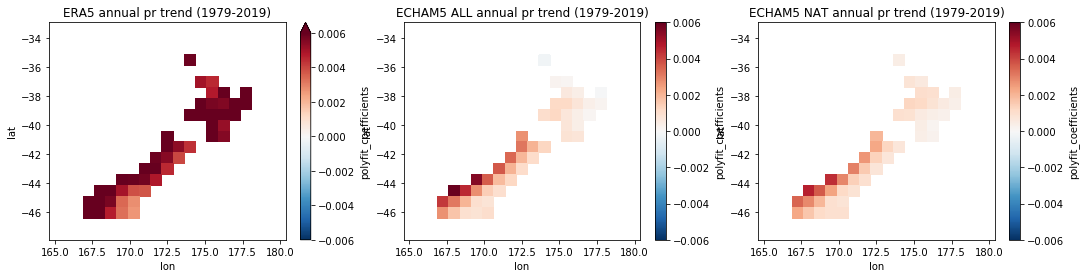

In [104]:
'''
plotting annual precip means, distributions, and trends
'''

# MEANS

#ECHAM5_pr_all_annual.mean('time').plot()
#plt.title('ECHAM5 ALL pr (m/year) (1979-2019)')
#ECHAM5_pr_nat_annual.mean('time').plot()
#plt.title('ECHAM5 NAT pr (m/year) (1979-2019)')
#ERA5_tp_annual.mean('time').plot()
#plt.title('ERA5 pr (m/year) (1979-2019)')

# DISTRIBUTIONS

#plt.hist(ERA5_tp_annual.values.flatten(),bins=30)
#plt.xlim(0,6)
#plt.title('ERA5 annual pr distribution')
#plt.hist(ECHAM5_pr_all_annual.values.flatten(),bins=30)
#plt.xlim(0,6)
#plt.title('ECHAM5 ALL annual pr distribution')
#plt.hist(ECHAM5_pr_nat_annual.values.flatten(),bins=30)
#plt.xlim(0,6)
#plt.title('ECHAM5 NAT annual pr distribution')

# TRENDS

fig,axs = plt.subplots(1,3,figsize=(18,4))
axs = axs.flatten()

era5_poly_fit = ERA5_tp_annual.polyfit(dim='time',deg=1,skipna=True)
(era5_poly_fit.polyfit_coefficients.sel(degree=1)* 1e9 * 60 * 60 * 24 * 365).plot(ax=axs[0],vmin=-0.006,vmax=0.006,cmap='RdBu_r')
axs[0].set_title('ERA5 annual pr trend (1979-2019)')

echam5_all_poly_fit = ECHAM5_pr_all_annual.polyfit(dim='time',deg=1,skipna=True)
(echam5_all_poly_fit.polyfit_coefficients.sel(degree=1)* 1e9 * 60 * 60 * 24 * 365).plot(ax=axs[1],vmin=-0.006,vmax=0.006,cmap='RdBu_r')
axs[1].set_title('ECHAM5 ALL annual pr trend (1979-2019)')

echam5_nat_poly_fit = ECHAM5_pr_nat_annual.polyfit(dim='time',deg=1,skipna=True)
(echam5_nat_poly_fit.polyfit_coefficients.sel(degree=1)* 1e9 * 60 * 60 * 24 * 365).plot(ax=axs[2],vmin=-0.006,vmax=0.006,cmap='RdBu_r')
axs[2].set_title('ECHAM5 NAT annual pr trend (1979-2019)')


Text(0.5, 1.0, 'ECHAM5 NAT winter pr trend (1979-2019)')

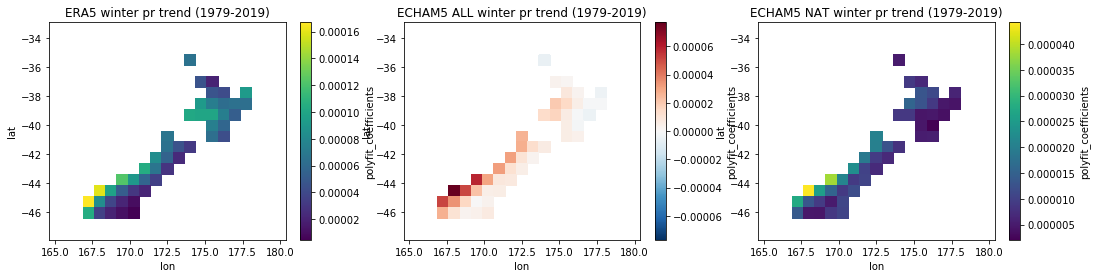

In [105]:
'''
plotting winter precip means, distributions, and trends
'''

ECHAM5_pr_all_winter = ECHAM5_pr_all_seasonal.sel(time=ECHAM5_pr_all_seasonal.time.dt.month.isin([6]))
ECHAM5_pr_nat_winter = ECHAM5_pr_nat_seasonal.sel(time=ECHAM5_pr_nat_seasonal.time.dt.month.isin([6]))
ERA5_tp_winter = ERA5_tp_seasonal.sel(time=ERA5_tp_seasonal.time.dt.month.isin([6]))

# MEANS

#ECHAM5_pr_all_winter.mean('time').plot()
#plt.title('ECHAM5 ALL winter (mm/day) pr (1979-2019)')
#ECHAM5_pr_nat_winter.mean('time').plot()
#plt.title('ECHAM5 NAT winter (mm/day) pr (1979-2019)')
#ERA5_tp_winter.mean('time').plot()
#plt.title('ERA5 winter (mm/day) pr (1979-2019)')

# DISTRIBUTIONS

#plt.hist(ERA5_tp_winter.values.flatten(),bins=30)
#plt.xlim(0,17.5)
#plt.title('ERA5 winter pr distribution')
#plt.hist(ECHAM5_pr_all_winter.values.flatten(),bins=30)
#plt.xlim(0,17.5)
#plt.title('ECHAM5 ALL winter pr distribution')
#plt.hist(ECHAM5_pr_nat_winter.values.flatten(),bins=30)
#plt.xlim(0,17.5)
#plt.title('ECHAM5 NAT winter pr distribution')

# TRENDS

fig,axs = plt.subplots(1,3,figsize=(18,4))
axs = axs.flatten()

era5_poly_fit = ERA5_tp_winter.polyfit(dim='time',deg=1,skipna=True)
(era5_poly_fit.polyfit_coefficients.sel(degree=1)* 1e9 * 60 * 60 * 24).plot(ax=axs[0],vmin=-0.006,vmax=0.006,cmap='RdBu_r')
axs[0].set_title('ERA5 winter pr trend (1979-2019)')

echam5_all_poly_fit = ECHAM5_pr_all_winter.polyfit(dim='time',deg=1,skipna=True)
(echam5_all_poly_fit.polyfit_coefficients.sel(degree=1)* 1e9 * 60 * 60 * 24).plot(ax=axs[1],vmin=-0.006,vmax=0.006,cmap='RdBu_r')
axs[1].set_title('ECHAM5 ALL winter pr trend (1979-2019)')

echam5_nat_poly_fit = ECHAM5_pr_nat_winter.polyfit(dim='time',deg=1,skipna=True)
(echam5_nat_poly_fit.polyfit_coefficients.sel(degree=1)* 1e9 * 60 * 60 * 24).plot(ax=axs[2],vmin=-0.006,vmax=0.006,cmap='RdBu_r')
axs[2].set_title('ECHAM5 NAT winter pr trend (1979-2019)')



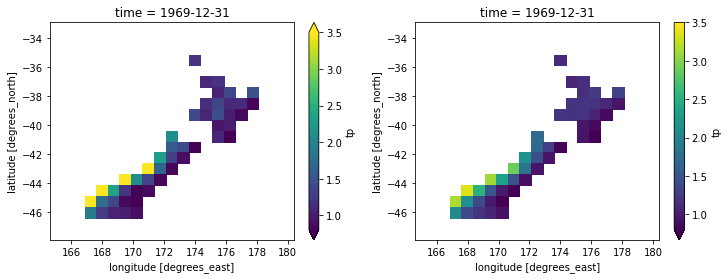

In [98]:
'''
plotting interp vs coarsen+interp for transforming ERA5 to ECHAM5 grid


fig,axs = plt.subplots(1,2,figsize=(12,4))
axs = axs.flatten()

ERA5_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/monthly/1969_2019.nc')
ERA5_ds = ERA5_ds.interp(longitude=ECHAM5_pr_all.lon, latitude=ECHAM5_pr_all.lat, method="linear")
ERA5_ds = ERA5_ds.tp.where(ECHAM5_land_mask.sftlf > 0)

ds = ERA5_ds.resample(time='A').mean().isel(time=0)*365

ds.plot(ax=axs[0],vmin=0.8,vmax=3.5)

ERA5_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/monthly/1969_2019.nc')
ERA5_ds = ERA5_ds.coarsen(latitude=3,longitude=3,boundary='trim').mean()
ERA5_ds = ERA5_ds.interp(longitude=ECHAM5_pr_all.lon, latitude=ECHAM5_pr_all.lat, method="linear")
ERA5_ds = ERA5_ds.tp.where(ECHAM5_land_mask.sftlf > 0)

ds = ERA5_ds.resample(time='A').mean().isel(time=0)*365

ds.plot(ax=axs[1],vmin=0.8,vmax=3.5)
'''